# Analyse du fichier concaténé

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../DATA/Data_concat/donnees_compilees.csv')
data.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2,ranking
0,A N Gratchev,2023-01-01,2,0.2,0,0.0,0,0.0,2,0.2,...,0,0.0,0,0,0,0,0,0,0.000000,8735
1,A N Gratchev,2024-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,3,0.076447,8223
2,A N Gratchev,2025-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0,0.0,0,0,0,0,3,6,0.129972,5888
3,Aadel A Chaudhuri,2023-01-01,2,6.9,0,0.0,0,0.0,2,6.9,...,0,0.0,0,0,0,0,0,0,0.000000,1935
4,Aadel A Chaudhuri,2024-01-01,3,0.3,1,0.1,0,0.0,2,0.2,...,0,0.0,1,0,0,1,53,67,4.834006,2155
5,Aadel A Chaudhuri,2025-01-01,2,29.8,1,29.7,0,0.0,1,0.1,...,0,0.0,0,0,0,0,7,14,1.064320,2307
6,Aakash Desai,2023-01-01,5,20.1,1,4.0,4,16.1,0,0.0,...,0,0.0,0,0,0,0,3,3,0.745592,285
7,Aakash Desai,2024-01-01,7,22.2,3,8.0,3,14.1,1,0.1,...,0,0.0,3,0,2,1,110,112,9.115923,300
8,Aakash Desai,2025-01-01,12,83.3,8,54.5,2,13.8,2,15.0,...,0,0.0,3,2,1,1,354,366,29.269657,309
9,Aaron Allen,2023-01-01,2,8.7,2,8.7,0,0.0,0,0.0,...,0,0.0,0,0,0,0,3,3,0.686332,9893


In [3]:
data['annee'] = pd.to_datetime(data['annee'])
data_2023 = data[data['annee'].dt.year == 2023]
data_2023_X = data_2023.drop(columns=['ranking'])
data_2023_X.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_sum_first_author_a-2,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2
0,A N Gratchev,2023-01-01,2,0.2,0,0.0,0,0.0,2,0.2,...,0.0,0,0.0,0,0,0,0,0,0,0.000000
3,Aadel A Chaudhuri,2023-01-01,2,6.9,0,0.0,0,0.0,2,6.9,...,0.0,0,0.0,0,0,0,0,0,0,0.000000
6,Aakash Desai,2023-01-01,5,20.1,1,4.0,4,16.1,0,0.0,...,0.0,0,0.0,0,0,0,0,3,3,0.745592
9,Aaron Allen,2023-01-01,2,8.7,2,8.7,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,3,3,0.686332
12,Aaron Lisberg,2023-01-01,5,130.3,4,109.3,0,0.0,1,21.0,...,0.0,0,0.0,0,0,0,0,13,20,4.708899
15,Aaron N Hata,2023-01-01,3,48.8,3,48.8,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,16,17,4.060993
18,Aaron R Dezube,2023-01-01,0,0.0,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,6,10,1.432042
21,Aaron S Mansfield,2023-01-01,4,104.5,4,104.5,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,40,41,11.102760
24,Aaron Tan,2023-01-01,2,12.0,1,7.1,0,0.0,1,4.9,...,0.0,0,0.0,0,0,0,0,31,48,9.894903
27,Aasthaa Bansal,2023-01-01,1,0.1,1,0.1,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,0,0,0.000000


In [4]:
# On met 'entity' en index
data_clust = data_2023_X.set_index('entity')

# On ne garde que les colonnes numériques pour le clustering
X = data_clust.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K means

In [5]:
from sklearn.cluster import KMeans

# Choisis le nombre de clusters, par ex. k = 4
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())

                   cluster_kmeans
entity                           
A N Gratchev                    0
Aadel A Chaudhuri               0
Aakash Desai                    2
Aaron Allen                     0
Aaron Lisberg                   2


In [6]:
data_clust = data_clust.merge(
    data_2023[['entity', 'ranking']],   # on ne garde que ce qui est utile
    on='entity',
    how='left'                          # on garde toutes les lignes de data_clust
)

In [7]:
# Moyenne du ranking par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].mean())

# Statistiques détaillées par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].describe())

cluster_kmeans
0    7164.307400
1    1199.323529
2     456.587580
Name: ranking, dtype: float64
                  count         mean          std    min      25%     50%  \
cluster_kmeans                                                              
0               12378.0  7164.307400  3728.667957  198.0  3869.00  7679.0   
1                  34.0  1199.323529  2165.936857    1.0    28.75   104.5   
2                 628.0   456.587580   368.736353    4.0   181.00   371.0   

                    75%      max  
cluster_kmeans                    
0               11105.0  13044.0  
1                 674.5   7679.0  
2                 628.0   2405.0  


In [8]:
data_clust[['entity', 'ranking']].head()

,entity,ranking
0,A N Gratchev,8735
1,Aadel A Chaudhuri,1935
2,Aakash Desai,285
3,Aaron Allen,9893
4,Aaron Lisberg,558


<Figure size 800x500 with 0 Axes>

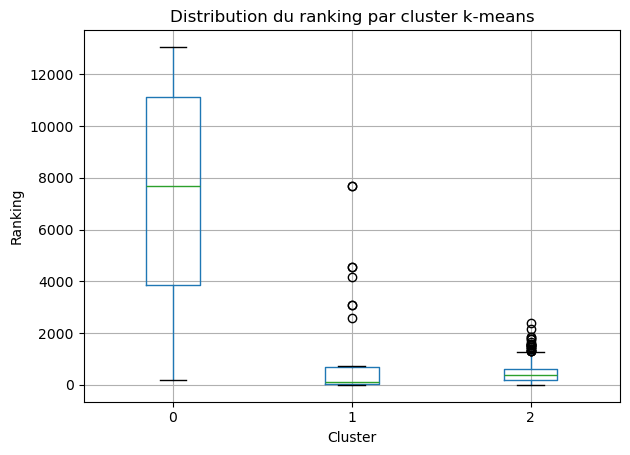

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_kmeans')
plt.title("Distribution du ranking par cluster k-means")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [10]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Modèle : ranking ~ cluster (traité comme facteur)
model = ols('ranking ~ C(cluster_kmeans)', data=data_clust).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                         sum_sq       df            F  PR(>F)
C(cluster_kmeans)  2.797070e+10      2.0  1058.090283     0.0
Residual           1.723171e+11  13037.0          NaN     NaN


In [11]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
print(centers)

   pub_count_publications  pub_sum_Impact_factor  pub_count_Author  \
0               -0.142740              -0.124147         -0.132056   
1                3.200404               4.867833          2.790632   
2                2.640157               2.183410          2.451757   

   pub_sum_author  pub_count_First_Author  pub_sum_first_author  \
0       -0.113930               -0.050756             -0.063033   
1        4.340533                0.724978              1.951912   
2        2.010584                0.961168              1.136715   

   pub_count_Last_Author  pub_sum_last_author  guid_count_publications  \
0              -0.090210            -0.079612                -0.019692   
1               2.752189             4.040573                 4.819622   
2               1.629044             1.350401                 0.127197   

   guid_sum_Impact_factor  ...  guid_sum_first_author_a-2  \
0               -0.019692  ...                  -0.008757   
1                4.819622  ... 

In [12]:
# Variance des centres par variable
importance = centers.var(axis=0)  # variance sur les lignes (clusters)

importance_sorted = importance.sort_values(ascending=False)
print(importance_sorted)

guid_sum_Impact_factor_a-1     124.397856
guid_count_publications_a-1    124.397856
guid_sum_author_a-1            116.840626
guid_count_Author_a-1          116.840626
cong_count_speaker              13.421350
                                  ...    
guid_count_Author_a-2            0.000028
nombre_session_congress_a-2      0.000000
cong_count_chair_a-2             0.000000
cong_count_poster_a-2            0.000000
cong_count_speaker_a-2           0.000000
Length: 69, dtype: float64


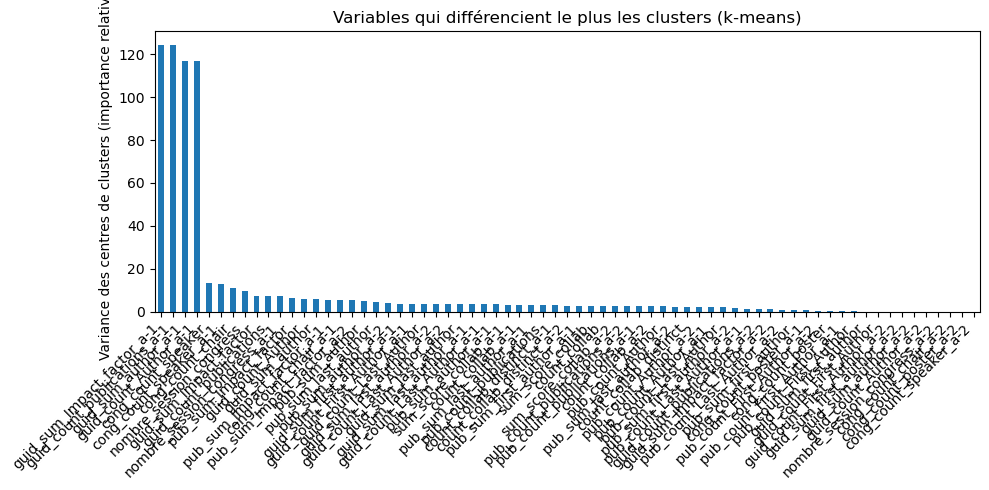

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
importance_sorted.to_csv("../OUTPUTS/Var_kmeans_importance_2023.csv")

## Clustering hiérarchique

In [15]:
from sklearn.cluster import AgglomerativeClustering

# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust['cluster_hier'] = hclust_labels

print(data_clust[['cluster_hier']].head())
print(data_clust['cluster_hier'].value_counts())

   cluster_hier
0             1
1             1
2             1
3             1
4             1
cluster_hier
1    12712
0      327
2        1
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

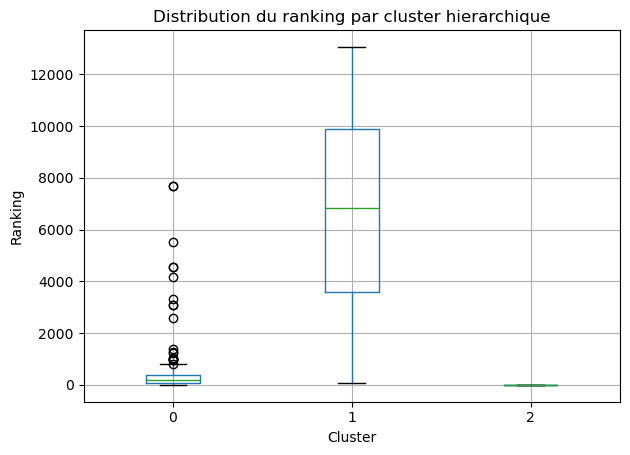

In [16]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_hier')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [17]:
# Mapping pour cluster_kmeans
mapping_kmeans = {
    0: "Other",
    1: "KOL",
    2: "RS"
}

# Mapping pour cluster_hier
mapping_hier = {
    0: "RS",
    1: "Other",
    2: "KOL"
}

data_clust["cluster_kmeans"] = data_clust["cluster_kmeans"].replace(mapping_kmeans)
data_clust["cluster_hier"]   = data_clust["cluster_hier"].replace(mapping_hier)

In [18]:
ct = pd.crosstab(data_clust['cluster_kmeans'],
                 data_clust['cluster_hier'])
print(ct)

cluster_hier    KOL  Other   RS
cluster_kmeans                 
KOL               1      0   33
Other             0  12363   15
RS                0    349  279


## Dendogramme

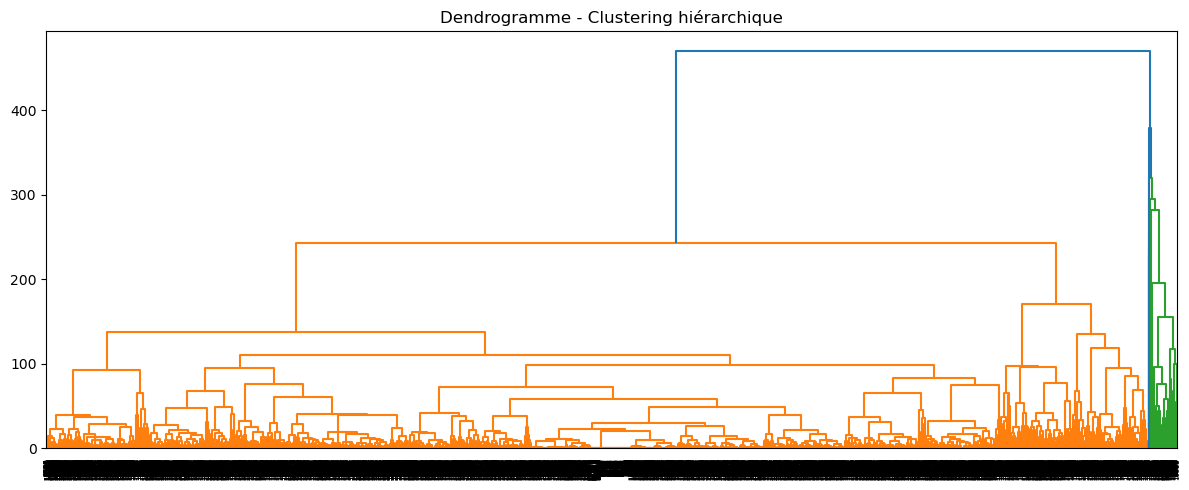

In [19]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# Matrice de liaison
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, labels=data_clust.index.to_list(), leaf_rotation=90)
plt.title("Dendrogramme - Clustering hiérarchique")
plt.tight_layout()
plt.show()

In [20]:
data_clust_2023 = data_clust
data_clust_2023.to_csv("../OUTPUTS/Res_clust_2023.csv", index=False)

# 2024

In [21]:
# data['annee'] = pd.to_datetime(data['annee'])
data_2024 = data[data['annee'].dt.year == 2024]
data_2024_X = data_2024.drop(columns=['ranking'])
data_2024_X.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_sum_first_author_a-2,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2
1,A N Gratchev,2024-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0.0,0,0.0,0,0,0,0,3,3,0.076447
4,Aadel A Chaudhuri,2024-01-01,3,0.3,1,0.1,0,0.0,2,0.2,...,0.0,0,0.0,1,0,0,1,53,67,4.834006
7,Aakash Desai,2024-01-01,7,22.2,3,8.0,3,14.1,1,0.1,...,0.0,0,0.0,3,0,2,1,110,112,9.115923
10,Aaron Allen,2024-01-01,0,0.0,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,0,0,0.000000
13,Aaron Lisberg,2024-01-01,4,54.4,3,51.8,0,0.0,1,2.6,...,0.0,0,0.0,2,0,2,1,339,344,32.526344
16,Aaron N Hata,2024-01-01,1,29.7,1,29.7,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,32,34,2.531394
19,Aaron R Dezube,2024-01-01,0,0.0,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,8,9,0.532504
22,Aaron S Mansfield,2024-01-01,5,68.8,4,65.8,0,0.0,1,3.0,...,0.0,0,0.0,5,0,3,2,323,336,30.156900
25,Aaron Tan,2024-01-01,5,30.6,2,21.0,2,5.2,1,4.4,...,0.0,0,0.0,0,0,0,0,30,52,3.982868
28,Aasthaa Bansal,2024-01-01,0,0.0,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,3,9,0.659509


In [22]:
# On met 'entity' en index
data_clust = data_2024_X.set_index('entity')

# On ne garde que les colonnes numériques pour le clustering
X = data_clust.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Kmeans

In [23]:
# Choisis le nombre de clusters, par ex. k = 4
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())

                   cluster_kmeans
entity                           
A N Gratchev                    0
Aadel A Chaudhuri               0
Aakash Desai                    1
Aaron Allen                     0
Aaron Lisberg                   1


In [24]:
data_clust = data_clust.merge(
    data_2024[['entity', 'ranking']],   # on ne garde que ce qui est utile
    on='entity',
    how='left'                          # on garde toutes les lignes de data_clust
)

# Moyenne du ranking par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].mean())

# Statistiques détaillées par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].describe())

cluster_kmeans
0    7135.600370
1     436.012048
2    1382.243902
Name: ranking, dtype: float64
                  count         mean          std    min     25%     50%  \
cluster_kmeans                                                             
0               12419.0  7135.600370  3767.977510  175.0  3865.0  7354.0   
1                 581.0   436.012048   386.869462    4.0   172.0   333.0   
2                  41.0  1382.243902  2649.038408    1.0    26.0   105.0   

                    75%      max  
cluster_kmeans                    
0               10436.0  13045.0  
1                 573.0   2743.0  
2                 514.0  10436.0  


<Figure size 800x500 with 0 Axes>

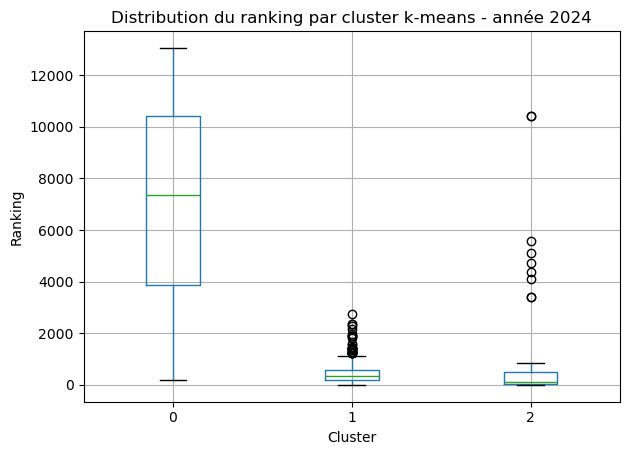

In [25]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_kmeans')
plt.title("Distribution du ranking par cluster k-means - année 2024")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [26]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
# Variance des centres par variable
importance = centers.var(axis=0)  # variance sur les lignes (clusters)

importance_sorted = importance.sort_values(ascending=False)
print(importance_sorted)

guid_sum_Impact_factor_a-2     85.553195
guid_count_publications_a-2    85.553195
guid_sum_author_a-2            80.355798
guid_count_Author_a-2          80.355798
guid_sum_Impact_factor_a-1     31.060110
                                 ...    
guid_count_publications         0.303537
guid_count_First_Author         0.012879
guid_sum_first_author           0.012879
guid_sum_author                 0.009634
guid_count_Author               0.009634
Length: 69, dtype: float64


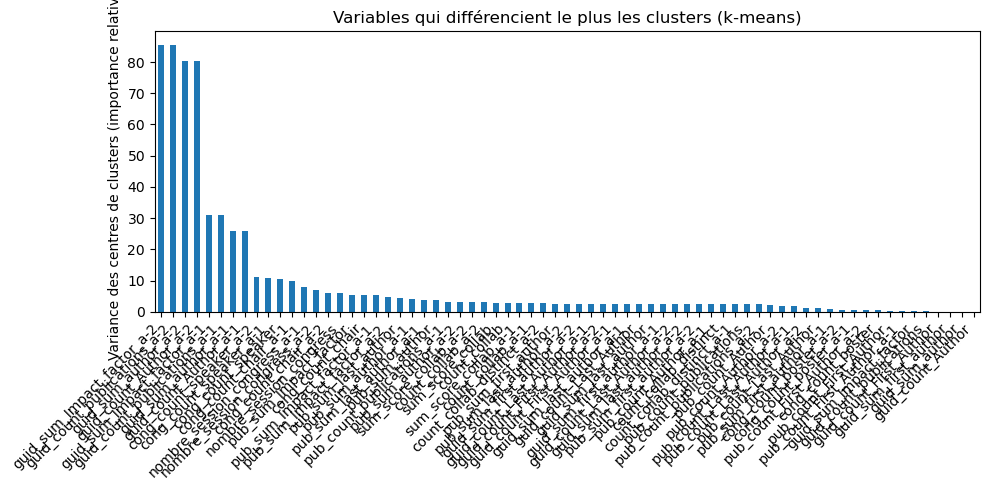

In [27]:
plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
importance_sorted.to_csv("../OUTPUTS/Var_kmeans_importance_2024.csv")

## Clustering hiérarchique

In [29]:
# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust['cluster_hier'] = hclust_labels

print(data_clust[['cluster_hier']].head())
print(data_clust['cluster_hier'].value_counts())

   cluster_hier
0             1
1             1
2             1
3             1
4             1
cluster_hier
1    12700
0      329
2       12
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

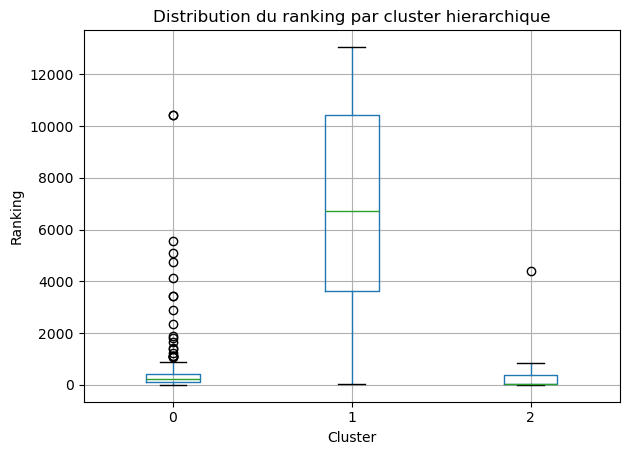

In [30]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_hier')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [31]:
# Mapping pour cluster_kmeans
mapping_kmeans = {
    0: "Other",
    1: "RS",
    2: "KOL"
}

# Mapping pour cluster_hier
mapping_hier = {
    0: "RS",
    1: "Other",
    2: "KOL"
}

data_clust["cluster_kmeans"] = data_clust["cluster_kmeans"].replace(mapping_kmeans)
data_clust["cluster_hier"]   = data_clust["cluster_hier"].replace(mapping_hier)

In [32]:
ct = pd.crosstab(data_clust['cluster_kmeans'],
                 data_clust['cluster_hier'])
print(ct)

cluster_hier    KOL  Others     RS
cluster_kmeans                    
KOL              29      12      0
Others           40       0  12379
RS              260       0    321


In [33]:
data_clust_2024 = data_clust
data_clust_2024.to_csv("../OUTPUTS/Res_clust_2024.csv", index=False)

# 2025

In [34]:
data_2025 = data[data['annee'].dt.year == 2025]
data_2025_X = data_2025.drop(columns=['ranking'])
data_2025_X.head(10)

,entity,annee,pub_count_publications,pub_sum_Impact_factor,pub_count_Author,pub_sum_author,pub_count_First_Author,pub_sum_first_author,pub_count_Last_Author,pub_sum_last_author,...,guid_sum_first_author_a-2,guid_count_Last_Author_a-2,guid_sum_last_author_a-2,nombre_session_congress_a-2,cong_count_chair_a-2,cong_count_poster_a-2,cong_count_speaker_a-2,count_collab_distinct_a-2,count_collab_a-2,sum_score_collab_a-2
2,A N Gratchev,2025-01-01,1,0.1,0,0.0,0,0.0,1,0.1,...,0.0,0,0.0,0,0,0,0,3,6,0.129972
5,Aadel A Chaudhuri,2025-01-01,2,29.8,1,29.7,0,0.0,1,0.1,...,0.0,0,0.0,0,0,0,0,7,14,1.064320
8,Aakash Desai,2025-01-01,12,83.3,8,54.5,2,13.8,2,15.0,...,0.0,0,0.0,3,2,1,1,354,366,29.269657
11,Aaron Allen,2025-01-01,1,6.4,1,6.4,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,13,16,0.937068
14,Aaron Lisberg,2025-01-01,5,80.7,4,75.9,1,4.8,0,0.0,...,0.0,0,0.0,2,0,1,1,182,191,14.253355
17,Aaron N Hata,2025-01-01,5,193.5,5,193.5,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,16,16,1.002136
20,Aaron R Dezube,2025-01-01,0,0.0,0,0.0,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,0,0,0.000000
23,Aaron S Mansfield,2025-01-01,3,11.3,3,11.3,0,0.0,0,0.0,...,0.0,0,0.0,2,0,2,1,266,274,21.685218
26,Aaron Tan,2025-01-01,6,90.3,4,84.2,0,0.0,2,6.1,...,0.0,0,0.0,0,0,0,0,5,5,0.344684
29,Aasthaa Bansal,2025-01-01,1,0.1,1,0.1,0,0.0,0,0.0,...,0.0,0,0.0,0,0,0,0,3,3,0.186879


In [35]:
# On met 'entity' en index
data_clust = data_2025_X.set_index('entity')

# On ne garde que les colonnes numériques pour le clustering
X = data_clust.select_dtypes(include=['number'])

# Normalisation (fortement recommandé pour k-means et clustering hiérarchique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Kmeans

In [36]:
# Choisis le nombre de clusters, par ex. k = 4
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data_clust['cluster_kmeans'] = kmeans_labels

# Visualiser les premiers résultats
print(data_clust[['cluster_kmeans']].head())

                   cluster_kmeans
entity                           
A N Gratchev                    0
Aadel A Chaudhuri               0
Aakash Desai                    1
Aaron Allen                     0
Aaron Lisberg                   1


In [37]:
data_clust = data_clust.merge(
    data_2025[['entity', 'ranking']],   # on ne garde que ce qui est utile
    on='entity',
    how='left'                          # on garde toutes les lignes de data_clust
)

# Moyenne du ranking par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].mean())

# Statistiques détaillées par cluster
print(data_clust.groupby('cluster_kmeans')['ranking'].describe())

cluster_kmeans
0    7063.773285
1     324.751606
2     532.666667
Name: ranking, dtype: float64
                  count         mean          std    min     25%     50%  \
cluster_kmeans                                                             
0               12562.0  7063.773285  3810.775697  140.0  3843.0  7053.0   
1                 467.0   324.751606   276.151950    3.0   126.0   259.0   
2                  12.0   532.666667  1229.499849    1.0    15.5    37.5   

                    75%      max  
cluster_kmeans                    
0               10904.0  13045.0  
1                 445.0   2105.0  
2                 424.0   4334.0  


<Figure size 800x500 with 0 Axes>

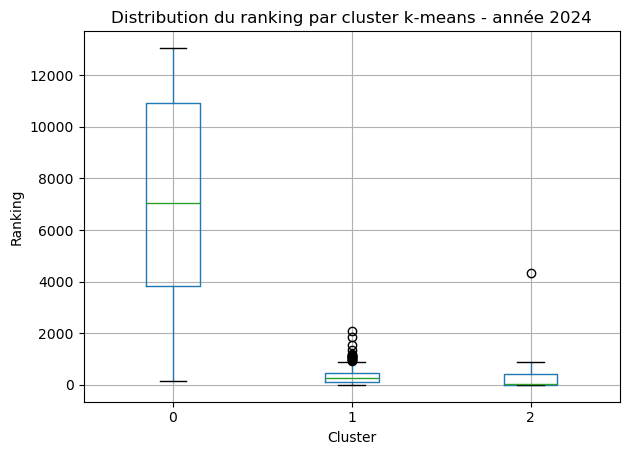

In [38]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_kmeans')
plt.title("Distribution du ranking par cluster k-means - année 2025")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

In [39]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
# Variance des centres par variable
importance = centers.var(axis=0)  # variance sur les lignes (clusters)

importance_sorted = importance.sort_values(ascending=False)
importance_sorted.to_csv("../OUTPUTS/Var_kmeans_importance_2025.csv")
print(importance_sorted)

guid_sum_Impact_factor_a-2     362.583640
guid_count_publications_a-2    362.583640
guid_sum_author_a-2            302.106659
guid_count_Author_a-2          302.106659
cong_count_speaker_a-1          31.629722
                                  ...    
guid_sum_Impact_factor           0.000000
guid_count_publications          0.000000
guid_sum_first_author            0.000000
guid_count_Last_Author           0.000000
guid_sum_last_author             0.000000
Length: 69, dtype: float64


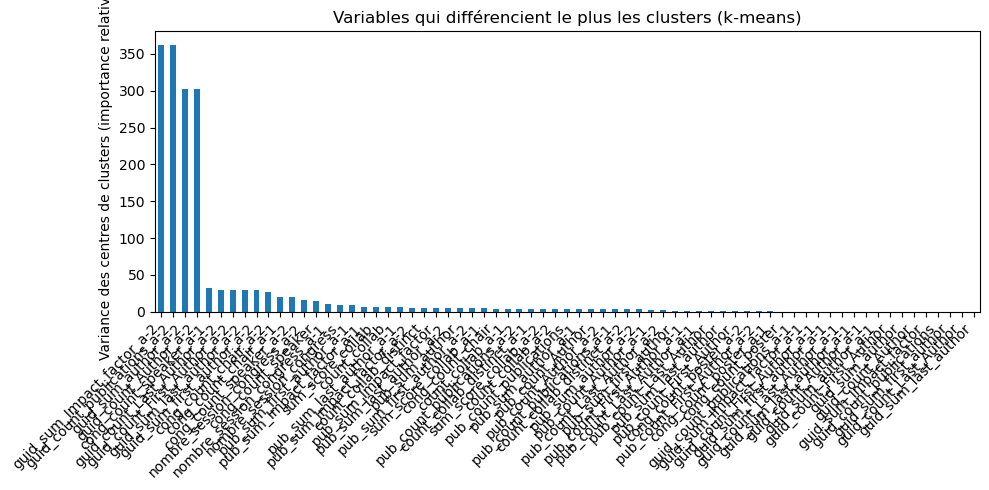

In [40]:
plt.figure(figsize=(10, 5))
importance_sorted.plot(kind='bar')
plt.ylabel("Variance des centres de clusters (importance relative)")
plt.title("Variables qui différencient le plus les clusters (k-means)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Clust hier

In [41]:
# Choisis le nombre de clusters, par ex. 4
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
hclust_labels = hclust.fit_predict(X_scaled)

data_clust['cluster_hier'] = hclust_labels

print(data_clust[['cluster_hier']].head())
print(data_clust['cluster_hier'].value_counts())

   cluster_hier
0             1
1             1
2             0
3             1
4             0
cluster_hier
1    12455
0      574
2       12
Name: count, dtype: int64


<Figure size 800x500 with 0 Axes>

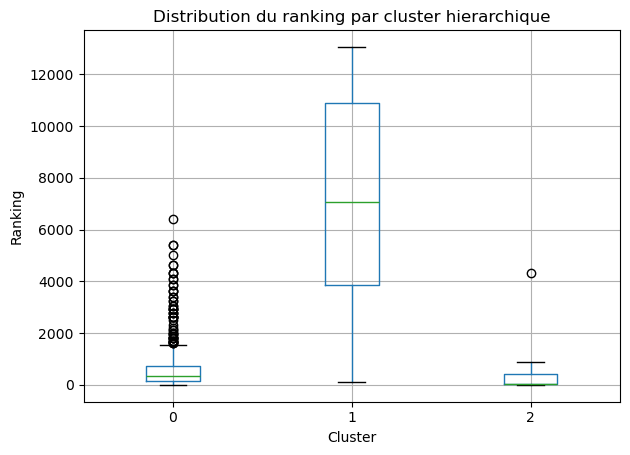

In [42]:
plt.figure(figsize=(8, 5))
data_clust.boxplot(column='ranking', by='cluster_hier')
plt.title("Distribution du ranking par cluster hierarchique")
plt.suptitle("")  # enlever le titre automatique
plt.xlabel("Cluster")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()